In [9]:
from multiprocessing import current_process
from netgen.meshing import *
from netgen.csg import *
from netgen.occ import *
from ngsolve import *
from ngsolve.fem import MixedFE
from ngsolve.webgui import Draw
from netgen.webgui import Draw as DrawGeo
import math
from numpy import *
import scipy.sparse as sp
import matplotlib.pylab as plt
from scipy.io import savemat
import scipy.sparse as sp

help(H1)

Help on class H1 in module ngsolve.comp:

class H1(FESpace)
 |  An H1-conforming finite element space.
 |  
 |  The H1 finite element space consists of continuous and
 |  element-wise polynomial functions. It uses a hierarchical (=modal)
 |  basis built from integrated Legendre polynomials on tensor-product elements,
 |  and Jaboci polynomials on simplicial elements. 
 |  
 |  Boundary values are well defined. The function can be used directly on the
 |  boundary, using the trace operator is optional.
 |  
 |  The H1 space supports variable order, which can be set individually for edges, 
 |  faces and cells. 
 |  
 |  Internal degrees of freedom are declared as local dofs and are eliminated 
 |  if static condensation is on.
 |  
 |  The wirebasket consists of all vertex dofs. Optionally, one can include the 
 |  first (the quadratic bubble) edge basis function, or all edge basis functions
 |  into the wirebasket.
 |  
 |  Keyword arguments can be:
 |  
 |  order: int = 1
 |    order 

In [10]:
import os, sys
sys.path.append('../../ICCG/JP-MARs/SparseSolv')
import SparseSolvPy

In [ ]:
h=0.01
r=0.01
conductor = Cylinder((0,0,0), Z, r=r, h=h)
conductor.maxh=r/10.
Draw(conductor)

conductor.faces.name="conductorBND"
conductor.faces.Max(Z).name="out"
conductor.faces.Min(Z).name="in"
conductor.mat("sig")
crosssection = conductor.faces.Max(Z).mass
print(crosssection)

geo =OCCGeometry(conductor)
with TaskManager():
#    mesh = Mesh(geo.GenerateMesh(maxh=0.005)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(100)  
    #mesh = Mesh(geo.GenerateMesh()).Curve(0) 
    mesh = Mesh(geo.GenerateMesh(maxh=0.001)).Curve(3)
#    mesh = Mesh(geo.GenerateMesh(meshsize.very_coarse)).Curve(5)   
Draw (mesh)



In [12]:
edges_no=mesh.nedge
faces_no=mesh.nface
elements_no=mesh.ne
calcd_ndof = (mesh.nedge*3)+( mesh.nface*6)+( mesh.ne*3)
print('#nv=', mesh.nv)
print('#nedge=', mesh.nedge)
print('#nface=', mesh.nface)
print('#ne=', mesh.ne)
print(calcd_ndof)
order=1
fesT = HCurl(mesh, order=order, nograds=True, complex=False)
fesOmega = H1(mesh,  order=order, definedon="sig",  complex=False)
print ("Hcurl_ndof =", fesOmega.ndof)
print ("H1_ndof =", fesT.ndof)
print ("ndof =", fesOmega.ndof+fesT.ndof)

Omega, psi =fesOmega.TnT()
T, W =fesT.TnT()

c = 299792458.
mu = 4*math.pi*1e-7
eps = 1/(c*c*mu)
sigma=1e6

Rn=[]
Ln=[]
log1min=[]
ndof=[]
nstage=[]

#E = CoefficientFunction((0,0,1))
#J = sigma*E

#nv= 2971
#nedge= 17754
#nface= 28197
#ne= 13413
262683
Hcurl_ndof = 2971
H1_ndof = 17754
ndof = 20725


Dof= 17754    matrix size= 107076.0


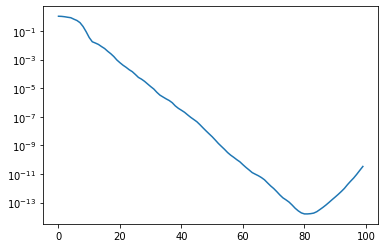

min: 1.618186601948934e-14
結果のノルム: 4.2857214141209324e-14
norm= 4.2857214141209324e-14


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.24…

BaseWebGuiScene

In [16]:
Es=CoefficientFunction((0,0,1))
n =specialcf.normal(mesh.dim)
a = BilinearForm(fesT)
a += 1/sigma*curl(T)*curl(W)*dx
f = LinearForm(fesT)
f += -Cross(Es, W.Trace())*n * ds("conductorBND")
with TaskManager():
    a.Assemble()
    f.Assemble()

gfT = GridFunction(fesT)

mat = sp.csr_matrix (a.mat.CSR())
#print(mat)
Acut = mat[:,fesT.FreeDofs()][fesT.FreeDofs(),:]
fcut = array(f.vec.FV())[fesT.FreeDofs()]
ucut = array(f.vec.FV(), copy=True)[fesT.FreeDofs()]

rows, cols = Acut.nonzero()
vals = Acut[rows, cols]
vals = ravel(vals)
dim=fcut.size
size= (len(rows)-dim)/2-dim
print('Dof=',dim, '   matrix size=', size)

mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)
solver = SparseSolvPy.MatSolvers()
solver.setSaveBest(True)
solver.setSaveLog(True)
solver.setDiagScale(False)
solver.setDirvegeType(1)
solver.setBadDivCount(10)
solver.setBadDivVal(10.0)
tol=1.e-16
max_iter=200
solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)

log1 = solver.getResidualLog_py()
#print(log1)

plt.plot(range(len(log1)), log1)    
plt.yscale('log')
plt.show(block=False)  

array(gfT.vec.FV(), copy=False)[fesT.FreeDofs()] = ucut
print("min:", min(log1))
#log1min.append(min(log1))

result = Acut.dot(ucut) - fcut
norm = linalg.norm(result)/linalg.norm(fcut)
print("結果のノルム:", norm)

result = Acut.dot(ucut) - fcut
norm = linalg.norm(result)/linalg.norm(fcut)
print("norm=", norm)

Draw(gfT,mesh(0,0,0))
Draw(curl(gfT)/sigma,mesh)

In [14]:
Tpot=gfT
J=curl(gfT)
E=J/sigma

nStage=0
R = 1/Integrate(sigma*E*E*dx, mesh)
Rn.append(R)
R_theory = (2*nStage+1)/(pi*r*r*sigma*h)
print("R_theory[",2*nStage,"]:", R_theory)
print("       R[",2*nStage,"]:", R)
R_err = abs(R - R_theory)/abs(R_theory)
print("     R_err[",2*nStage,"]:",R_err) 

R_theory[ 0 ]: 0.3183098861837906
       R[ 0 ]: 0.31828467613480504
     R_err[ 0 ]: 7.919970468959743e-05


1 -stage
Dof= 2971    matrix size= 14783.0


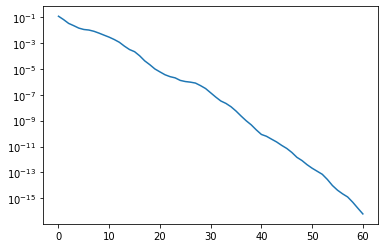

min: 6.144648822102333e-17
結果のノルム: 9.284802423536332e-16
L_theory[ 1 ]: 4.9999999999999996e-06
       L[ 1 ]: 4.999787600143536e-06
     L_err[ 1 ]: 4.247997129263411e-05
Dof= 17754    matrix size= 107076.0


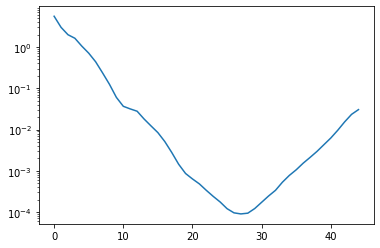

min: 9.02440662337678e-05
結果のノルム: 9.024406623277424e-05
norm= 9.024406623277424e-05
R_theory[ 2 ]: 0.9549296585513718
       R[ 2 ]: 0.9741644169527964
     R_err[ 2 ]: 0.020142591895830068
2 -stage
Dof= 2971    matrix size= 14783.0


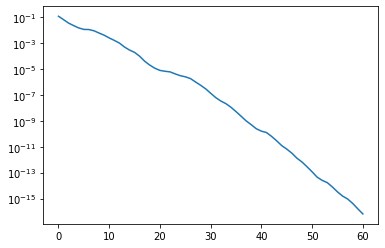

min: 6.695731738876935e-17
結果のノルム: 8.512929876050784e-16
L_theory[ 3 ]: 2.4999999999999998e-06
       L[ 3 ]: 2.716492006414104e-06
     L_err[ 3 ]: 0.0865968025656417
Dof= 17754    matrix size= 107076.0


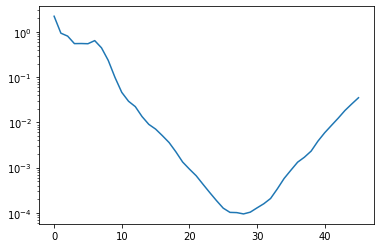

min: 9.463134681558247e-05
結果のノルム: 9.463134681555277e-05
norm= 9.463134681555277e-05
R_theory[ 4 ]: 1.591549430918953
       R[ 4 ]: 1.9849031923489502
     R_err[ 4 ]: 0.24715145743407826
3 -stage
Dof= 2971    matrix size= 14783.0


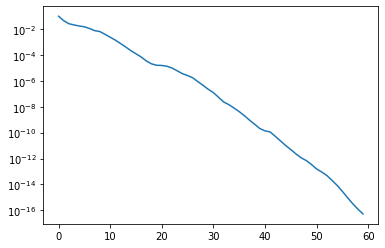

min: 5.102009810686033e-17
結果のノルム: 8.326563594886447e-16
L_theory[ 5 ]: 1.6666666666666667e-06
       L[ 5 ]: 2.546403531128157e-06
     L_err[ 5 ]: 0.5278421186768942
Dof= 17754    matrix size= 107076.0


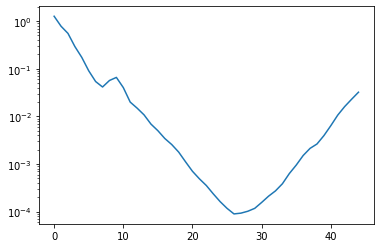

min: 8.944735384863283e-05
結果のノルム: 8.94473538485896e-05
norm= 8.94473538485896e-05
R_theory[ 6 ]: 2.228169203286534
       R[ 6 ]: 4.711808379135625
     R_err[ 6 ]: 1.1146546555736163
4 -stage
Dof= 2971    matrix size= 14783.0


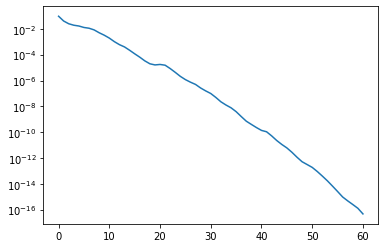

min: 4.7492285399951454e-17
結果のノルム: 7.662808808234727e-16
L_theory[ 7 ]: 1.2499999999999999e-06
       L[ 7 ]: 3.6638654354214373e-06
     L_err[ 7 ]: 1.93109234833715
Dof= 17754    matrix size= 107076.0


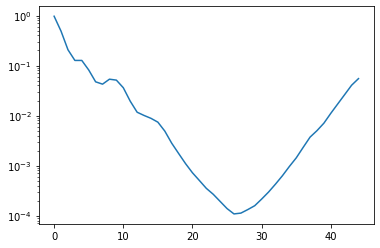

min: 0.00010833827753858638
結果のノルム: 0.0001083382775386384
norm= 0.0001083382775386384
R_theory[ 8 ]: 2.864788975654115
       R[ 8 ]: 12.009428255257747
     R_err[ 8 ]: 3.1920812867257156
5 -stage
Dof= 2971    matrix size= 14783.0


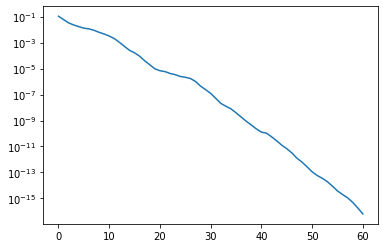

min: 6.381764450510306e-17
結果のノルム: 8.743941139379587e-16
L_theory[ 9 ]: 1e-06
       L[ 9 ]: 1.4071632059666492e-05
     L_err[ 9 ]: 13.071632059666491
Dof= 17754    matrix size= 107076.0


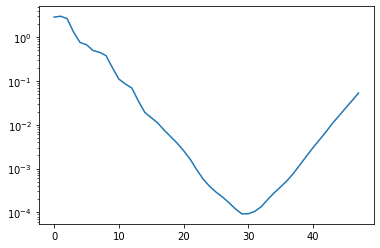

min: 9.189391611330677e-05
結果のノルム: 9.189391611275668e-05
norm= 9.189391611275668e-05
R_theory[ 10 ]: 3.5014087480216967
       R[ 10 ]: 1.1763858998870609
     R_err[ 10 ]: 0.6640249726480174
6 -stage
Dof= 2971    matrix size= 14783.0


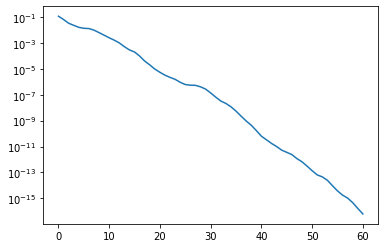

min: 6.28552296083471e-17
結果のノルム: 9.372943932456803e-16
L_theory[ 11 ]: 8.333333333333333e-07
       L[ 11 ]: 9.765197951111681e-06
     L_err[ 11 ]: 10.718237541334018
Dof= 17754    matrix size= 107076.0


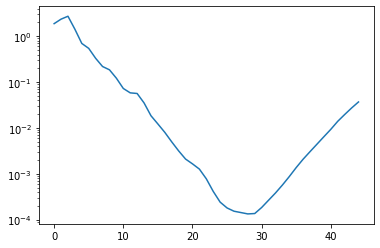

min: 0.00013377102794737345
結果のノルム: 0.0001337710279472313
norm= 0.0001337710279472313
R_theory[ 12 ]: 4.138028520389278
       R[ 12 ]: 8.414840388136206
     R_err[ 12 ]: 1.0335385188076458
7 -stage
Dof= 2971    matrix size= 14783.0


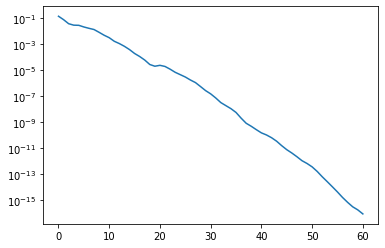

min: 8.704110578993704e-17
結果のノルム: 1.0460124924881621e-15
L_theory[ 13 ]: 7.142857142857143e-07
       L[ 13 ]: 4.9532483716699345e-05
     L_err[ 13 ]: 68.34547720337908
Dof= 17754    matrix size= 107076.0


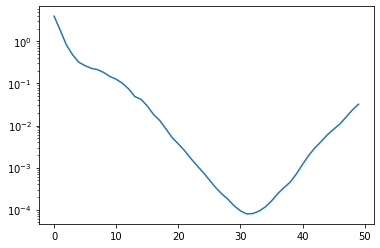

min: 7.924089622382793e-05
結果のノルム: 7.924089622287999e-05
norm= 7.924089622287999e-05
R_theory[ 14 ]: 4.774648292756859
       R[ 14 ]: 16.944191010921713
     R_err[ 14 ]: 2.5487830667289257
8 -stage
Dof= 2971    matrix size= 14783.0


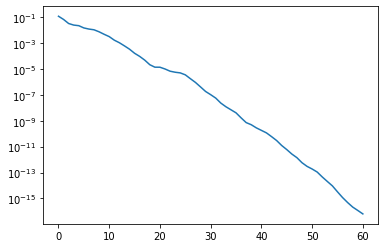

min: 6.268967291322087e-17
結果のノルム: 1.0605115911879514e-15
L_theory[ 15 ]: 6.249999999999999e-07
       L[ 15 ]: 1.0162866308387406e-05
     L_err[ 15 ]: 15.26058609341985
Dof= 17754    matrix size= 107076.0


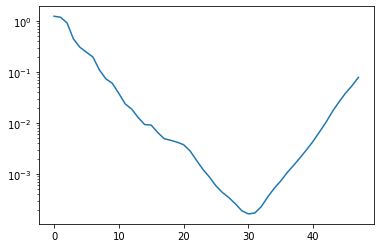

min: 0.00016394577066720632
結果のノルム: 0.0001639457706672251
norm= 0.0001639457706672251
R_theory[ 16 ]: 5.41126806512444
       R[ 16 ]: 6.079205394593778
     R_err[ 16 ]: 0.12343452984230935
9 -stage
Dof= 2971    matrix size= 14783.0


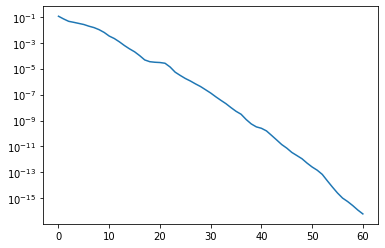

min: 6.26059290496874e-17
結果のノルム: 1.174923093158757e-15
L_theory[ 17 ]: 5.555555555555555e-07
       L[ 17 ]: 2.9057565613077662e-05
     L_err[ 17 ]: 51.30361810353979
Dof= 17754    matrix size= 107076.0


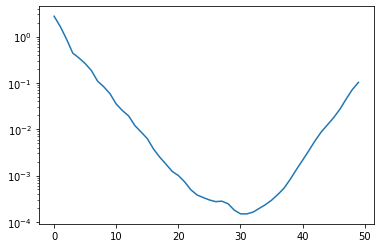

min: 0.00014850613740193647
結果のノルム: 0.00014850613740168044
norm= 0.00014850613740168044
R_theory[ 18 ]: 6.047887837492021
       R[ 18 ]: 26.364213153541257
     R_err[ 18 ]: 3.3592430716231916
10 -stage
Dof= 2971    matrix size= 14783.0


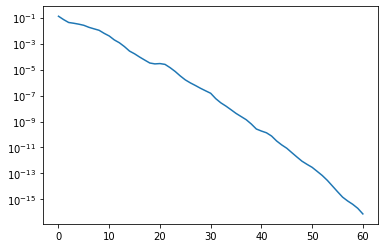

min: 7.566355409192171e-17
結果のノルム: 1.1565462548243786e-15
L_theory[ 19 ]: 5e-07
       L[ 19 ]: 7.249432035921608e-05
     L_err[ 19 ]: 143.98864071843218
Dof= 17754    matrix size= 107076.0


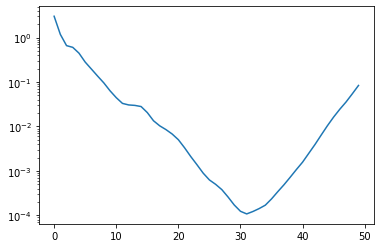

min: 0.00010772585265502049
結果のノルム: 0.00010772585265487585
norm= 0.00010772585265487585
R_theory[ 20 ]: 6.684507609859603
       R[ 20 ]: 26.91507647898566
     R_err[ 20 ]: 3.02648602558042


In [15]:
for nStage in range(10):
    print(nStage+1, "-stage")
    nstage.append(nStage+1)


    a = BilinearForm(fesOmega)
    a += mu*grad(Omega)*grad(psi)*dx
    f = LinearForm(fesOmega)
    f += -mu*grad(psi)*(Tpot) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    gfOmega = GridFunction(fesOmega)

    mat = sp.csr_matrix (a.mat.CSR())
    #print(A)
    Acut = mat[:,fesOmega.FreeDofs()][fesOmega.FreeDofs(),:]
    fcut = array(f.vec.FV())[fesOmega.FreeDofs()]
    ucut = array(f.vec.FV(), copy=True)[fesOmega.FreeDofs()]

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)
    
    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)

    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)
    
    
    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  
    
    array(gfOmega.vec.FV(), copy=False)[fesOmega.FreeDofs()] = ucut
    print("min:", min(log1))
    #log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)
    
    if nStage ==0:
        H= R*(Tpot+grad(gfOmega))
    else:
        H =H + R*(Tpot+grad(gfOmega))
    B=mu*H
    #B=curl(Apot)
    L = Integrate(B*B/mu*dx, mesh)
    Ln.append(L)
    L_theory = (mu)/(4*2*(nStage+1)*pi*h)
    print("L_theory[",2*nStage+1,"]:", L_theory)
    print("       L[",2*nStage+1,"]:", L)
    L_err = abs(L - L_theory)/abs(L_theory)
    print("     L_err[",2*nStage+1,"]:",L_err) 
    
    gfT = GridFunction(fesT)    
    a = BilinearForm(fesT)
    a += 1./sigma*curl(T)*curl(W)*dx
    f = LinearForm(fesT)
    f += W*(-B/L) * dx
    with TaskManager():
        a.Assemble()
        f.Assemble()

    mat = sp.csr_matrix (a.mat.CSR())
    #print(mat)
    Acut = mat[:,fesT.FreeDofs()][fesT.FreeDofs(),:]
    fcut = array(f.vec.FV())[fesT.FreeDofs()]
    ucut = array(f.vec.FV(), copy=True)[fesT.FreeDofs()]

    rows, cols = Acut.nonzero()
    vals = Acut[rows, cols]
    vals = ravel(vals)
    dim=fcut.size
    size= (len(rows)-dim)/2-dim
    print('Dof=',dim, '   matrix size=', size)

    mat = SparseSolvPy.SparseMat(len(rows), rows, cols, vals)
    solver = SparseSolvPy.MatSolvers()
    solver.setSaveBest(True)
    solver.setSaveLog(True)
    solver.setDiagScale(False)
    solver.setDirvegeType(1)
    solver.setBadDivCount(10)
    solver.setBadDivVal(10.0)
    tol=1.e-16
    max_iter=200
    solver.solveICCG_py(len(fcut), tol, max_iter, 1.1, mat, fcut, ucut, True)

    log1 = solver.getResidualLog_py()
    #print(log1)

    plt.plot(range(len(log1)), log1)    
    plt.yscale('log')
    plt.show(block=False)  

    array(gfT.vec.FV(), copy=False)[fesT.FreeDofs()] = ucut
    print("min:", min(log1))
#log1min.append(min(log1))

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("結果のノルム:", norm)

    result = Acut.dot(ucut) - fcut
    norm = linalg.norm(result)/linalg.norm(fcut)
    print("norm=", norm)
    
    Tpot=Tpot+gfT
    J=J+curl(gfT)
    E=J/sigma

    R = 1/Integrate(sigma*E*E*dx, mesh)
    
    if nStage<10-1:
        Rn.append(R)
    
    R_theory = (2*nStage+3)/(pi*r*r*sigma*h)
    print("R_theory[",2*nStage+2,"]:", R_theory)
    print("       R[",2*nStage+2,"]:", R)
    R_err = abs(R - R_theory)/abs(R_theory)
    print("     R_err[",2*nStage+2,"]:",R_err) 

data = {'Rn': Rn, 'Ln': Ln}
FileName = f"TOmega_{order}.mat"  
savemat(FileName,data)